In [1]:
import os
import yaml
import multiprocessing as mp
import time
import tools21cm as t2c
from tqdm import tqdm
import astropy.units as u
import astropy.constants as cst
import cupy as cp
import numpy as np
import itertools

import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "serif"

from scipy.interpolate import make_interp_spline

from matplotlib.colors import LogNorm

In [48]:
def cupy_antenna_distances(antenna_coords):
    # Number of antennas
    n = antenna_coords.shape[0]
    
    # Generate indices for all possible pairs
    idx_i, idx_j = np.triu_indices(n, k=1)
    idx_i = cp.asarray(idx_i)
    idx_j = cp.asarray(idx_j)
    
    # Get the coordinates for these pairs
    coords1 = antenna_coords[idx_i]
    coords2 = antenna_coords[idx_j]
    
    # Compute the squared differences
    diff = coords2 - coords1   
    
    return diff


def synchrotron_image(z, ncells, boxsize, seed=False):
    """Generate a synchrotron image.

    Parameters:
    - z (float): Redshift value.
    - ncells (int): Number of cells in each dimension.
    - boxsize (float): Size of the box in Mpc.
    - seed (bool, optional): Whether to use a fixed seed for random number generation. Default is False.

    Returns:
    - T_real (ndarray): The real part of the synchrotron image.
    - l_cb (ndarray): The angular scale of the synchrotron image.
    """
    if seed:
        np.random.seed(seed)

    X = np.random.normal(size=(ncells, ncells))
    Y = np.random.normal(size=(ncells, ncells))

    A150, beta = 5.13 * 1e-4, 2.34

    U_cb = (
        (np.mgrid[-ncells / 2 : ncells / 2, -ncells / 2 : ncells / 2] + 0.5)
        * t2c.cosmo.z_to_cdist(z)
        / boxsize
    )
    l_cb = 2 * np.pi * np.sqrt(U_cb[0, :, :] ** 2 + U_cb[1, :, :] ** 2)
    C_syn = A150 * (1000 / l_cb) ** beta
    solid_angle = boxsize**2 / t2c.cosmo.z_to_cdist(z) ** 2
    AA = np.sqrt(solid_angle * C_syn / 2)
    T_four = AA * (X + Y * 1j) * np.sqrt(2)
    T_real = np.abs(np.fft.ifft2(T_four))

    return T_real, l_cb


def telescope_beam_pattern_thetafwhm(x, y, theta_fwhm):
    theta_0 = 0.6* theta_fwhm
    return np.exp(-((x**2 + y**2) / theta_0**2))


def filter_baselines_cupy(baselines, visibilities, u_freq, v_freq):
    """Filters baselines and corresponding visibilities based on the range of
    frequencies. This is so that the baselines outside the frequency range of
    the fft image are removed.

    Parameters:
    baselines (ndarray): Numpy array of baseline coordinates.
    visibilities (ndarray): Numpy array of corresponding visibilities.
    u_freq (ndarray): Numpy array of u frequencies.
    v_freq (ndarray): Numpy array of v frequencies.

    Returns:
    filtered_baselines (ndarray): CuPy array of filtered baseline coordinates.
    filtered_visibilities (ndarray): CuPy array of filtered visibilities.
    """
    # Convert inputs to CuPy arrays
    baselines_cp = cp.array(baselines)
    visibilities_cp = cp.array(visibilities)
    u_freq_cp = cp.array(u_freq)
    v_freq_cp = cp.array(v_freq)
    
    # Find the min and max frequencies
    u_min, u_max = cp.min(u_freq_cp), cp.max(u_freq_cp)
    v_min, v_max = cp.min(v_freq_cp), cp.max(v_freq_cp)
    
    # Filter baselines based on frequency range
    x = baselines_cp[:, 0]
    y = baselines_cp[:, 1]
    mask = (u_min <= x) & (x <= u_max) & (v_min <= y) & (y <= v_max)
    
    # Apply mask to baselines and visibilities
    filtered_baselines = baselines_cp[mask]
    filtered_visibilities = visibilities_cp[mask]
    
    return filtered_baselines, filtered_visibilities


def visibility_matrix_func_new_method_cupy(xyz_coord, sky_coord, redshift, I_sky, beam_pattern):
    # Convert inputs to CuPy arrays
    xyz_coord = cp.array(xyz_coord)
    sky_coord = cp.array(sky_coord)
    I_sky = cp.array(I_sky)
    beam_pattern = cp.array(beam_pattern)

    l_coord, m_coord = cp.meshgrid(sky_coord, sky_coord)
    N_ant = len(xyz_coord)
    N_B = N_ant * (N_ant - 1) // 2
    freq = t2c.cosmo.z_to_nu(redshift) * 1e6
    lam = cst.c.value / freq
    pair_comb = list(itertools.combinations(range(N_ant), 2))
    baseline_coord = cp.empty((N_B, xyz_coord.shape[1]))
    visibility_matrix = cp.zeros((N_ant, N_ant), dtype=cp.complex128)
    visibility_list = cp.empty(N_B, dtype=cp.complex128)

    for i in tqdm(range(N_B)):
        aa, bb = pair_comb[i]
        uv = (xyz_coord[bb] - xyz_coord[aa]) / lam
        baseline_coord[i] = uv
        fringe = cp.exp(-2j * cp.pi * (uv[0] * l_coord + uv[1] * m_coord))
        vis = cp.sum(fringe * I_sky * beam_pattern)
        visibility_list[i] = vis
        visibility_matrix[aa, bb] = vis
        visibility_matrix[bb, aa] = cp.conj(vis)
    
    # Transfer results back to CPU if needed
    visibility_list = cp.asnumpy(visibility_list)
    visibility_matrix = cp.asnumpy(visibility_matrix)
    baseline_coord = cp.asnumpy(baseline_coord)
    
    return visibility_list, visibility_matrix, baseline_coord

***
## __All functions for the cupy option.__

In [3]:
def _splice_values_equal_bins_cupy(blcoord_sorted, blmag_sorted, vis_sorted, num_bins):
    """
    The provided arrays should be cupy arrays.
    """
    # Step 1: Calculate the number of elements per bin
    num_elements = len(blmag_sorted)
    elements_per_bin = num_elements // num_bins
    extra_elements = num_elements % num_bins

    # Step 2: Create an array of bin sizes
    bin_sizes = cp.full(num_bins, elements_per_bin)
    bin_sizes[:extra_elements] += 1

    # Step 3: Calculate the cumulative sum of bin sizes
    cumulative_sizes = cp.cumsum(bin_sizes)
    cumulative_sizes_np = cp.asnumpy(cumulative_sizes)  # Convert to NumPy array

    # Step 4: Initialize the bins
    blcoord_bins = cp.split(blcoord_sorted, cumulative_sizes_np[:-1])
    blmag_bins = cp.split(blmag_sorted, cumulative_sizes_np[:-1])
    vis_bins = cp.split(vis_sorted, cumulative_sizes_np[:-1])

    return blcoord_bins, blmag_bins, vis_bins

def _splice_values_function_fit_cupy(blmag_sorted_transformed, blcoord_sorted, blmag_sorted, vis_sorted, num_bins):
    bins = cp.linspace(np.min(blmag_sorted_transformed), np.max(blmag_sorted_transformed), num_bins)
    bin_indices = np.digitize(blmag_sorted_transformed, bins) - 1
    
    # Use histogram to count the occurrences of each bin
    hist, _ = cp.histogram(bin_indices, bins=cp.arange(0, num_bins + 1))

    # Calculate the cumulative counts to determine the indices where each bin's values start and end
    cum_counts = cp.cumsum(hist)
    cumulative_sizes_np = cp.asnumpy(cum_counts)  # Convert to NumPy array

    bin_blcoords = cp.split(blcoord_sorted, cumulative_sizes_np[:-1])
    bin_vis = cp.split(vis_sorted, cumulative_sizes_np[:-1])
    bin_blmags = cp.split(blmag_sorted, cumulative_sizes_np[:-1])

    return bin_blcoords, bin_vis, bin_blmags


def compute_vals_cupy(blcoord, vis, sigma_0, V_0, bin_number):

    bin_len = len(blcoord)
    if bin_len == 0 or bin_len == 1:
        return 0, 0, 0

    # Create a meshgrid for vectorized pairwise operations
    idx_i, idx_j = np.triu_indices(bin_len, k=1)
    idx_i = cp.asarray(idx_i)
    idx_j = cp.asarray(idx_j)

    # Calculate pairwise distances
    delta= blcoord[idx_i] - blcoord[idx_j]
    distance_norm = cp.linalg.norm(delta, axis=1)
    
    combination_len_unfiltered= len(distance_norm)
    
    # Filter pairs where distance is less than or equal to sigma_0
    valid_pairs = distance_norm > sigma_0
    if not cp.any(valid_pairs):
        return 0, 0, 0

    distance_norm = distance_norm[valid_pairs]
    idx_i = idx_i[valid_pairs]
    idx_j = idx_j[valid_pairs]
    
    combination_len_filtered= len(distance_norm)
    print("Bin", bin_number, ":Theoretical combinations: ", combination_len_unfiltered,
         " - When filtered: ", combination_len_filtered)
    
    # Calculate weights
    weight = cp.exp(-(distance_norm**2) / sigma_0**2)

    # Calculate the visibility product
    visibility_product = vis[idx_i] * cp.conj(vis[idx_j])

    #Calclating the bare estimator
    be_numerator = cp.sum(weight * visibility_product)
    be_denominator = cp.sum(weight * V_0 * cp.exp(-(distance_norm**2) / (sigma_0**2)))

    #Calculating the mean of ell
    l_i = 2 * cp.pi * cp.sqrt(blcoord[idx_i, 0]**2 + blcoord[idx_i, 1]**2)
    exp_weight_distance = weight * cp.exp(-(distance_norm**2) / (sigma_0**2))

    ell_numerator = cp.sum(exp_weight_distance * l_i)
    ell_denominator = cp.sum(exp_weight_distance)

    #Computing arrays needed for the error (variance)
    Eb_square_mean_numerator = cp.sum((exp_weight_distance * 5.13 * 1e-4 * (1000 / l_i) ** 2.34) ** 2)
    Eb_mean_square_numerator = cp.sum(exp_weight_distance * 5.13 * 1e-4 * (1000 / l_i) ** 2.34)
    Eb_denominator = cp.sum(exp_weight_distance)

    bare_estimator = cp.abs(be_numerator) / be_denominator
    ell_mean = ell_numerator / ell_denominator
    var_squared = (Eb_square_mean_numerator / Eb_denominator - (Eb_mean_square_numerator / Eb_denominator) ** 2)

    # Convert results back to numpy arrays
    bare_estimator = cp.asnumpy(bare_estimator)
    ell_mean = cp.asnumpy(ell_mean)
    var_squared = cp.asnumpy(var_squared)

    return bare_estimator, ell_mean, np.abs(var_squared)


def bare_estimator_func_cupy(baselines, visibilities, theta_fwhm, num_bins, bin_type):
    theta_0 = 0.6 * theta_fwhm
    V_0 = np.pi * theta_0**2 / 2
    sigma_0 = 0.76 / theta_fwhm

    start_time = time.time()
    # Step 0: turn arrays into cupy arrays
    baselines= cp.asarray(baselines, dtype= cp.float32)
    visibilities= cp.asarray(visibilities, dtype= cp.complex64)

    # Step 1: Calculate the baseline magnitudes
    bl_mag = cp.linalg.norm(baselines, axis=1)

    # Stack baselines, magnitudes, and visibilities into a single array for sorting
    #combined_array = cp.hstack((baselines[:,0, None], baselines[:,1, None], bl_mag[:, None], visibilities[:, None]))
    combined_array = cp.hstack((baselines[:], bl_mag[:, None], visibilities[:, None]))

    # Sort the combined array based on the magnitudes
    sorted_combined_array = combined_array[cp.argsort(combined_array[:,2])]

    # Split the sorted array back into individual components
    blcoord_sorted = sorted_combined_array[:, 0:2]
    blcoord_sorted = blcoord_sorted.astype(cp.float32)  # Change to desired dtype
    blmag_sorted = sorted_combined_array[:, 2]
    blmag_sorted = blmag_sorted.astype(cp.float32)      # Change to desired dtype
    vis_sorted = sorted_combined_array[:, -1]
    vis_sorted = vis_sorted.astype(cp.complex64)          # Change to desired dtype

    print("Length of input arrays: ", len(blmag_sorted))

    if bin_type == "log":
        blmag_sorted_transformed = cp.log10(blmag_sorted)
        blcoord_bins, blmag_bins, vis_bins = _splice_values_function_fit_cupy(blmag_sorted_transformed, blcoord_sorted, blmag_sorted, vis_sorted, num_bins)

    elif bin_type == "linear":
        blmag_sorted_transformed = blmag_sorted
        blcoord_bins, blmag_bins, vis_bins = _splice_values_function_fit_cupy(blmag_sorted_transformed, blcoord_sorted, blmag_sorted, vis_sorted, num_bins)

    elif bin_type == "equal_length":
        blcoord_bins, blmag_bins, vis_bins = _splice_values_equal_bins_cupy(blcoord_sorted, blmag_sorted, vis_sorted, num_bins)
    else:
        raise ValueError("Unsupported bin_type")

    end_time = time.time()
    print('Time to sort and bin values: ', end_time-start_time, 's')

    # Verify the bins
    for i, bin in enumerate(blcoord_bins):
        print(f"Bin {i+1}: {len(bin)} elements - Combinations: {int(len(bin)*(len(bin)-1) / 2)}")
    # Print to verify the results
    print("Total elements after binning: ", cp.sum(cp.array([len(bin) for bin in blmag_bins])))

    bare_estimators = np.empty(num_bins, dtype=np.float32)
    average_ells = np.empty(num_bins, dtype=np.float32)
    square_variances = np.empty(num_bins, dtype=np.float32)

    start_time = time.time()
    for i in range(num_bins):
        bin_number = i + 1
        BE, ell_avg, var_squared= compute_vals_cupy(blcoord_bins[i], vis_bins[i], sigma_0, V_0, bin_number) 

        bare_estimators[i] = BE
        average_ells[i] = ell_avg
        square_variances[i] = var_squared
    end_time = time.time()
    print('Time to run the bare estimator: ', end_time-start_time, 's')
    
    return bare_estimators, average_ells, square_variances

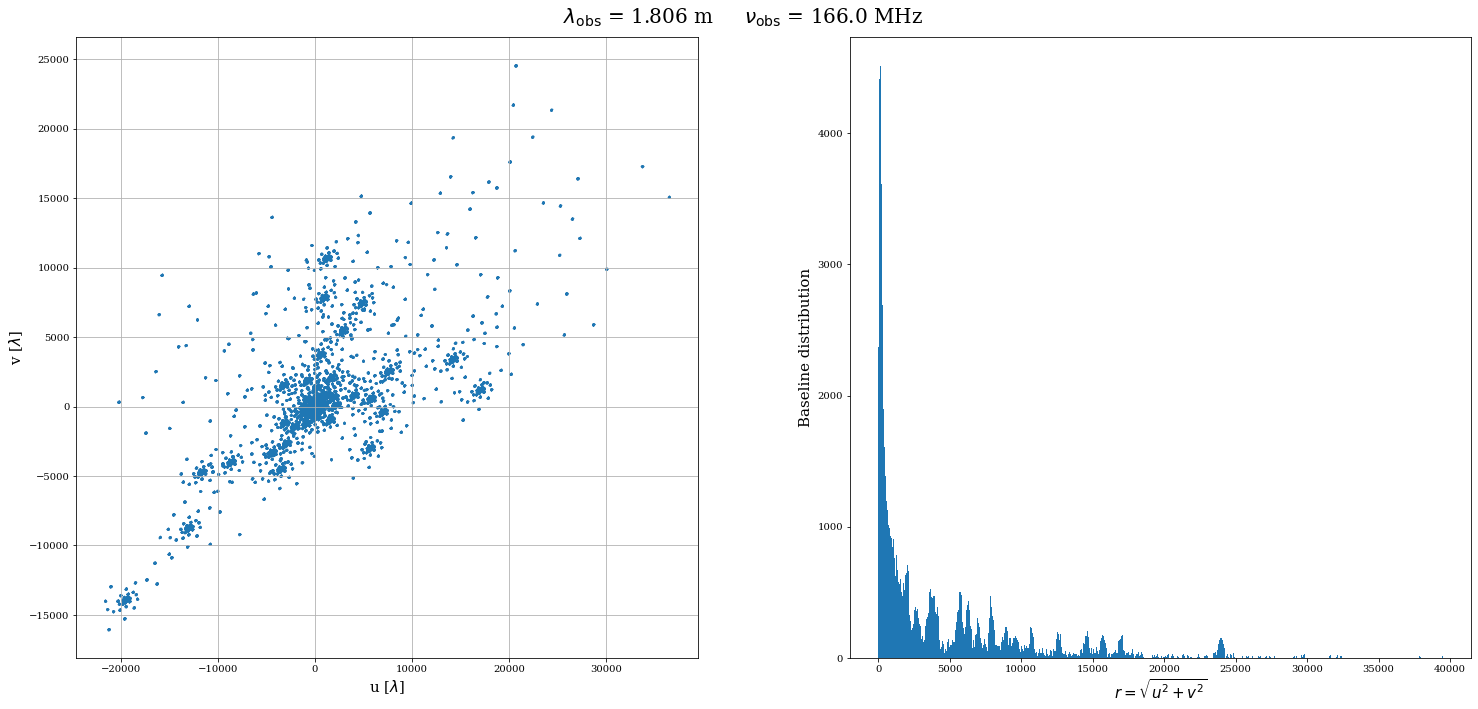

In [4]:
ant_coords = cp.load('SKA_material/SKA_ant_coords.npy')
#Calculating distances between all possible antenna combinations
pair_distances = cupy_antenna_distances(ant_coords)

frequency = 1.66 * 1e8
lam = cst.c.value / frequency
rshift = t2c.cosmo.nu_to_z(frequency / 1e6)

baselines = pair_distances / lam
baseline_norms = cp.linalg.norm(baselines, axis = 1)

#For beam statstics
theta_maj= 0.0441370233211219
theta_min= 0.0329175084774813
theta_fwhm = np.mean([theta_maj, theta_min])

fig, axs= plt.subplots(1, 2, figsize=(22, 10))

plt.suptitle(r'$\lambda_{\rm obs}$ = %.3f m     $\nu_{\rm obs}$ = %.1f MHz' %(lam, frequency / 1e6), fontsize= 20)

axs[0].scatter(cp.asnumpy(baselines[:,0]), cp.asnumpy(baselines[:,1]), s=0.5, color= 'tab:blue')
axs[0].grid()
axs[0].set_box_aspect(1)
axs[0].set_xlabel(r'u [$\lambda$]', fontsize = 15)
axs[0].set_ylabel(r'v [$\lambda$]', fontsize = 15)

axs[1].hist(cp.asnumpy(baseline_norms), bins= 1000) 
axs[1].set_box_aspect(1)
axs[1].set_xlabel(r'$r = \sqrt{u^2 + v^2}$', fontsize = 15)
axs[1].set_ylabel('Baseline distribution', fontsize = 15)
plt.tight_layout()


In [5]:
def visibility_computation(baselines, sky_coord, I_sky, beam_pattern):
        l_coord, m_coord= cp.meshgrid(sky_coord, sky_coord)
        visibility_list= cp.empty(len(baselines), dtype=np.complex128)
        
        for i in tqdm(range(len(baselines))):
            fringe = cp.exp(-2j * np.pi * (baselines[i,0] * l_coord + baselines[i,1] * m_coord))
            vis = np.sum(fringe * I_sky * beam_pattern)
            visibility_list[i] = vis
            
        return visibility_list

In [7]:
FoV= 10. * u.deg

# define a 1D sky and get RA coordinate
thet = np.linspace(-FoV/2, FoV/2, 1024).to('rad').value
#thet = np.linspace(-FoV/2, FoV/2, 256).to('rad').value

# Create a grid of points (we ignore third dimension, i.e. n-axis)
l_coord, m_coord = np.meshgrid(thet, thet)
lmn_coord = np.dstack((l_coord, m_coord)).reshape(-1, 2)

#Angular diameter distance (in Mpc) for a specified redshift and FoV in deg
rshift = t2c.cosmo.nu_to_z(frequency / 1e6)
ang_dim_dist= FoV.to('rad').value * t2c.cosmo.z_to_cdist(rshift)

#Synchrotron source
synchro_source, l= synchrotron_image(z=[rshift], ncells=len(thet), boxsize=ang_dim_dist, seed=2024)

#Beam pattern
beam_pattern= telescope_beam_pattern(l_coord, m_coord, theta_fwhm)

#Computing the visibilities
visls = visibility_computation(cp.asarray(baselines), cp.asarray(thet), rshift, cp.asarray(synchro_source))

100%|██████████| 130816/130816 [02:58<00:00, 732.49it/s]


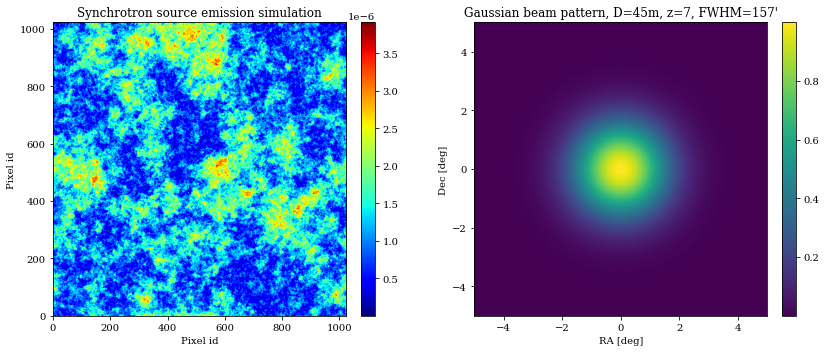

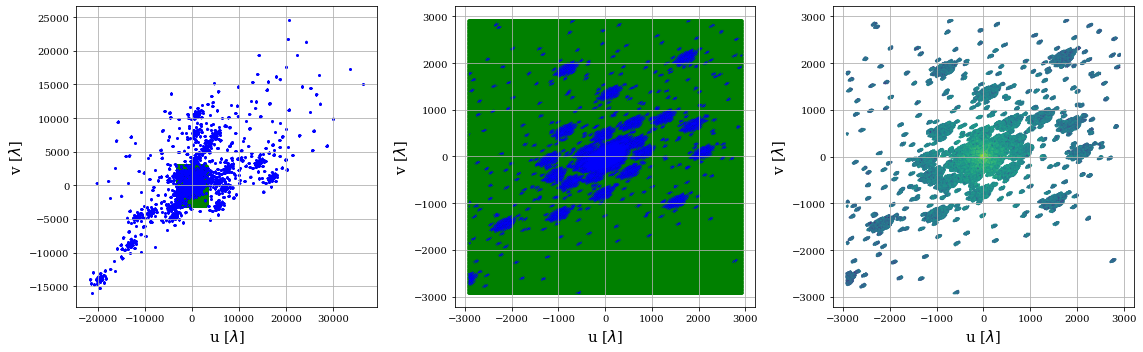

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
im0 = axes[0].imshow(synchro_source, cmap='jet', origin= 'lower')
axes[0].set_title("Synchrotron source emission simulation")
axes[0].set_ylabel('Pixel id')
axes[0].set_xlabel('Pixel id')
axes[0].set_box_aspect(1)
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].pcolormesh(np.rad2deg(l_coord), np.rad2deg(m_coord), beam_pattern, cmap='viridis')
axes[1].set_ylabel('Dec [deg]')
axes[1].set_xlabel('RA [deg]')
axes[1].set_title("Gaussian beam pattern, D=45m, z=7, FWHM=157'")
axes[1].set_box_aspect(1)
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()
#***********************************************


uu= np.fft.fftfreq(len(thet), np.diff(thet)[0])
vv= np.fft.fftfreq(len(thet), np.diff(thet)[0])
uu= np.fft.fftshift(uu)
vv= np.fft.fftshift(vv)
u_freq, v_freq= np.meshgrid(uu, vv)


#***********************************************
fig, axes= plt.subplots(1, 3, figsize=(16, 8))
axes[0].scatter(u_freq, v_freq, color='green', s=5)
axes[0].scatter(cp.asnumpy(baselines[:,0]), cp.asnumpy(baselines[:,1]), color='blue', s=0.5)
axes[0].set_xlabel(r'u [$\lambda$]', fontsize = 15)
axes[0].set_ylabel(r'v [$\lambda$]', fontsize = 15)
axes[0].set_box_aspect(1)
axes[0].grid()


bls_filter, visls_filter = filter_baselines_cupy(baselines, visls, u_freq, v_freq)
axes[1].scatter(u_freq, v_freq, color='green', s=0.5)
axes[1].scatter(cp.asnumpy(bls_filter[:,0]), cp.asnumpy(bls_filter[:,1]), color='blue', s=0.01)
axes[1].set_xlabel(r'u [$\lambda$]', fontsize = 15)
axes[1].set_ylabel(r'v [$\lambda$]', fontsize = 15)
axes[1].set_box_aspect(1)
axes[1].grid()


im2 = axes[2].scatter(x=cp.asnumpy(bls_filter[:,0]), y=cp.asnumpy(bls_filter[:,1]), c=cp.asnumpy(cp.abs(visls_filter)), s=1, norm=LogNorm())
axes[2].set_xlabel(r'u [$\lambda$]', fontsize = 15)
axes[2].set_ylabel(r'v [$\lambda$]', fontsize = 15)
axes[2].set_box_aspect(1)
axes[2].grid()

plt.tight_layout()

In [9]:
num_bins = 20
binning_method= 'equal_length'

all_bare_ests  = np.empty(num_bins)
all_ell_means = np.empty(num_bins)
all_var_squares = np.empty(num_bins)

#Computing the bare estimator
bare_estimator, ell_mean, var_squared= bare_estimator_func_cupy(bls_filter, visls_filter, theta_fwhm, num_bins, binning_method)

ells = np.linspace(ell_mean[0], ell_mean[-1], 100)

"""
# Squeeze the arrays to remove single-dimensional entries
all_bare_ests[count] = np.squeeze(bare_estimator)
all_ell_means[count] = np.squeeze(ell_mean)
all_var_squares[count] = np.squeeze(var_squared)

bare_estimator_avg= np.mean(all_bare_ests, axis=0)
ell_mean_avg= np.mean(all_ell_means, axis=0)
var_squared_avg= np.mean(all_var_squares, axis=0)

print("Bare estimator values:", bare_estimator_avg)
print("Ell mean values:", ell_mean_avg)
print("Variance squared values:", var_squared_avg)

# Plot the results
full_file_path_plot = os.path.join(os.path.dirname("output/"), filename_plot)
plot(bare_estimator_avg, ell_mean_avg, var_squared_avg, file_path=full_file_path_plot, img_dpi=config['img_dpi'])

# Save the arrays as a numpy file
full_file_path_npz = os.path.join(os.path.dirname("output/"), filename_npz)
npz_filename = os.path.splitext(full_file_path_npz)[0] + ".npz"
np.savez(npz_filename, bare_estimator_avg=bare_estimator_avg, ell_mean_avg=ell_mean_avg, var_squared_avg=var_squared_avg)
"""

Length of input arrays:  76329
Time to sort and bin values:  1.2341978549957275 s
Bin 1: 3817 elements - Combinations: 7282836
Bin 2: 3817 elements - Combinations: 7282836
Bin 3: 3817 elements - Combinations: 7282836
Bin 4: 3817 elements - Combinations: 7282836
Bin 5: 3817 elements - Combinations: 7282836
Bin 6: 3817 elements - Combinations: 7282836
Bin 7: 3817 elements - Combinations: 7282836
Bin 8: 3817 elements - Combinations: 7282836
Bin 9: 3817 elements - Combinations: 7282836
Bin 10: 3816 elements - Combinations: 7279020
Bin 11: 3816 elements - Combinations: 7279020
Bin 12: 3816 elements - Combinations: 7279020
Bin 13: 3816 elements - Combinations: 7279020
Bin 14: 3816 elements - Combinations: 7279020
Bin 15: 3816 elements - Combinations: 7279020
Bin 16: 3816 elements - Combinations: 7279020
Bin 17: 3816 elements - Combinations: 7279020
Bin 18: 3816 elements - Combinations: 7279020
Bin 19: 3816 elements - Combinations: 7279020
Bin 20: 3816 elements - Combinations: 7279020
Total e

'\n# Squeeze the arrays to remove single-dimensional entries\nall_bare_ests[count] = np.squeeze(bare_estimator)\nall_ell_means[count] = np.squeeze(ell_mean)\nall_var_squares[count] = np.squeeze(var_squared)\n\nbare_estimator_avg= np.mean(all_bare_ests, axis=0)\nell_mean_avg= np.mean(all_ell_means, axis=0)\nvar_squared_avg= np.mean(all_var_squares, axis=0)\n\nprint("Bare estimator values:", bare_estimator_avg)\nprint("Ell mean values:", ell_mean_avg)\nprint("Variance squared values:", var_squared_avg)\n\n# Plot the results\nfull_file_path_plot = os.path.join(os.path.dirname("output/"), filename_plot)\nplot(bare_estimator_avg, ell_mean_avg, var_squared_avg, file_path=full_file_path_plot, img_dpi=config[\'img_dpi\'])\n\n# Save the arrays as a numpy file\nfull_file_path_npz = os.path.join(os.path.dirname("output/"), filename_npz)\nnpz_filename = os.path.splitext(full_file_path_npz)[0] + ".npz"\nnp.savez(npz_filename, bare_estimator_avg=bare_estimator_avg, ell_mean_avg=ell_mean_avg, var_squ

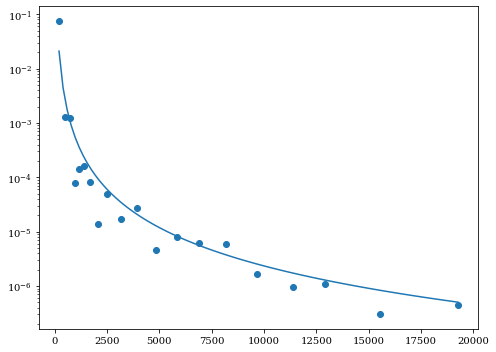

In [12]:
fig, axes = plt.subplots(1, 1, figsize=(7, 5))

axes.scatter(ell_mean, bare_estimator / 100)
axes.plot(ells, 5.13 * 1e-4 * (1000 / ells) ** 2.34)
axes.set_yscale('log')
plt.tight_layout()
plt.show()

***
## __Bare estimator for a random layout.__

In [8]:
from scipy import stats


def telescope_beam_pattern(x, y, D, z):
    """
    Returns a 2D Gaussian array representing the telescope beam pattern.

    Parameters
    ----------
    x : ndarray
        Meshgrid x-coordinates.
    y : ndarray
        Meshgrid y-coordinates.
    D : float, optional
        Telescope dish diameter, in meters (default is 45).
    z : float, optional
        Redshift, which is converted to observation frequency (default is 7).

    Returns
    -------
    ndarray
        A 2D Gaussian array representing the telescope beam pattern.

    Notes
    -----
    The Gaussian array is calculated based on the provided dish diameter and redshift.
    """
    freq= t2c.cosmo.z_to_nu(z) * 10**6
    lam = cst.c.value / freq
    fwhm= 1.03*lam / D
    theta_0 = 0.6* fwhm
    return np.exp(-((x**2 + y**2) / theta_0**2))


def visibility_matrix_func_new_method(xyz_coord, sky_coord, redshift, I_sky, beam_pattern):
    l_coord, m_coord= np.meshgrid(sky_coord, sky_coord)
    N_ant= len(xyz_coord)
    N_B= int(N_ant*(N_ant-1) / 2)
    freq = t2c.cosmo.z_to_nu(redshift) * 10**6
    lam = cst.c.value / freq
    pair_comb= list(itertools.combinations(range(N_ant), 2))
    baseline_coord= np.empty((N_B, xyz_coord.shape[1]))
    visibility_matrix= np.zeros((N_ant, N_ant), dtype=np.complex128)
    visibility_list= np.empty(N_B, dtype=np.complex128)

    for i in tqdm(range(N_B)):
        aa, bb= pair_comb[i]
        uv= (xyz_coord[bb]- xyz_coord[aa]) / lam
        baseline_coord[i]= uv
        fringe= np.exp(-2j * np.pi * (uv[0] * l_coord + uv[1] * m_coord))
        vis= np.sum(fringe * I_sky * beam_pattern)
        visibility_list[i]= vis
        visibility_matrix[aa, bb]= vis
        visibility_matrix[bb, aa]= np.conj(vis)
    
    return visibility_list, visibility_matrix, baseline_coord


def random_layout(N_ant, range, seed):
    """
    Generates a random layout of antennas within the specified range.

    Parameters
    ----------
    N_ant : int
        Number of antennas to generate.
    range : tuple
        Tuple specifying the range of coordinates in which antennas will be placed.
        It should be in the format (min_value, max_value).
    seed : int
        Seed value for random number generation.

    Returns
    -------
    ndarray
        An array containing the coordinates of the randomly placed antennas.
        Each row represents the (x, y) coordinates of an antenna.
    """

    np.random.seed(seed)
    X= np.random.uniform(range[0], range[1], N_ant)
    Y= np.random.uniform(range[0], range[1], N_ant)

    return np.dstack((X,Y)).reshape(-1, 2)


def image_reconstructing_func(vis_list, baselines, u_min, u_max, bin_len, bin_res):
    """
    Reconstructs an image from visibility data using interferometry.

    Parameters:
    vis_list (array-like): List of visibility values.
    baselines (array-like): List of baseline coordinates.
    u_min (float): Minimum value of the u-coordinate.
    u_max (float): Maximum value of the u-coordinate.
    bin_len (float): Length of the bin.
    bin_res (float): Resolution of the bin.

    Returns:
    array-like: Reconstructed image.
    """
    uv_bin= np.linspace(u_min, u_max, int(bin_len/ bin_res))
    
    uv_plane_binned= stats.binned_statistic_2d(x=baselines[:,0], y=baselines[:,1], values= vis_list,
                                               statistic='sum', bins=[uv_bin, uv_bin]).statistic
    uv_sampl_binned= stats.binned_statistic_2d(x=baselines[:,0], y=baselines[:,1], values= vis_list,
                                               statistic='count', bins=[uv_bin, uv_bin]).statistic
    uv_plane_binned /= np.where(uv_sampl_binned > 0, uv_sampl_binned, 1)

    x= np.fft.fftshift(np.fft.fftfreq(len(uv_bin), np.diff(uv_bin)[0]))

    return uv_plane_binned, uv_bin, uv_sampl_binned, x


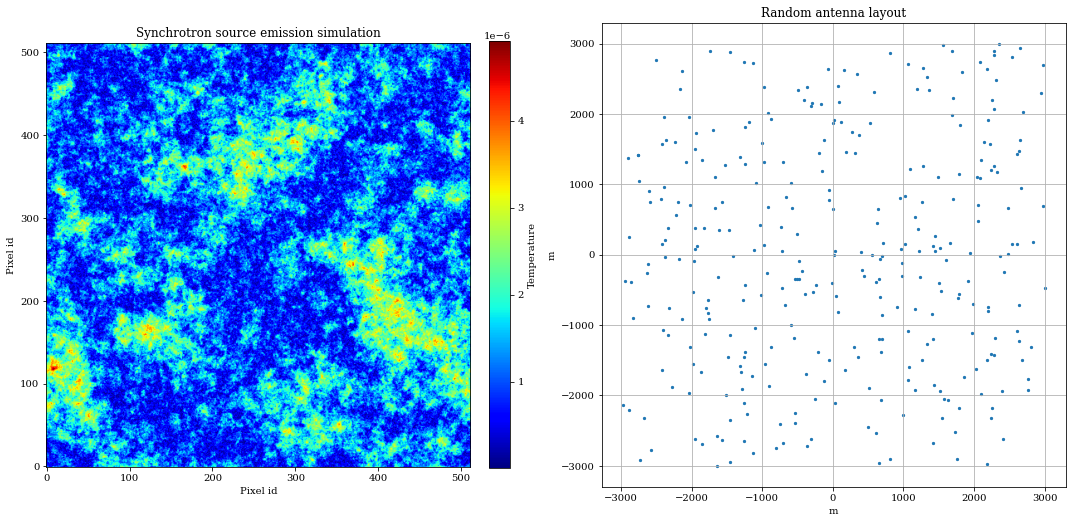

100%|██████████| 52326/52326 [00:20<00:00, 2554.92it/s]


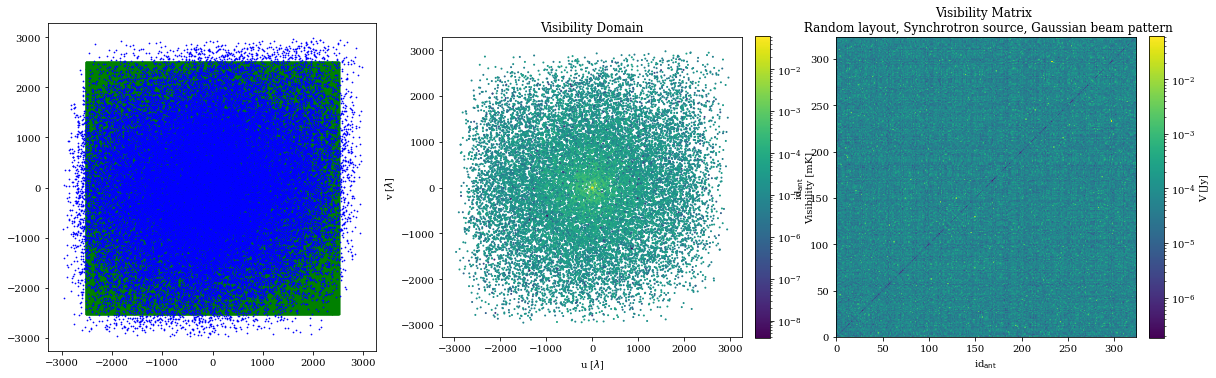

In [10]:
FoV= 5.8*u.deg

# define a 1D sky and get RA coordinate
thet = np.linspace(-FoV/2, FoV/2, 512).to('rad').value

# Create a grid of points (we ignore third dimension, i.e. n-axis)
l_coord, m_coord = np.meshgrid(thet, thet)
lmn_coord = np.dstack((l_coord, m_coord)).reshape(-1, 2)

#***********************************************
# Generate the coordinates of the telescope layout
xyz_random= random_layout(18**2, [-3000., 3000.], 2024)
#xyz_random= random_layout(9**2, [-1500., 1500.], 2024)
#***********************************************

# Angular diameter distance (in Mpc) for a specified redshift and FoV in deg
rshift=8.52
com_dist= FoV.to('rad').value * t2c.cosmo.z_to_cdist(rshift)

#Computing theta_fwhm
freq = t2c.cosmo.z_to_nu(rshift) * 10**6
lam = cst.c.value / freq
D = 45    
theta_fwhm= 1.03*lam / D

# Gaussian and synchrotron sources, beam pattern
synchro_source, l= synchrotron_image(rshift, len(thet), com_dist, seed=2024)
beam_pattern= telescope_beam_pattern(l_coord, m_coord, D=45, z=rshift)

#***********************************************
fig, axes = plt.subplots(1, 2, figsize=(15, 10))

im1 = axes[0].imshow(synchro_source, cmap='jet', origin= 'lower')
axes[0].set_title("Synchrotron source emission simulation")
axes[0].set_ylabel('Pixel id')
axes[0].set_xlabel('Pixel id')
axes[0].set_box_aspect(1)
plt.colorbar(im1, ax=axes[0], label='Temperature', fraction=0.046, pad=0.04)

axes[1].scatter(xyz_random[:, 0], xyz_random[:, 1], s=5)
axes[1].set_xlabel("m")
axes[1].set_ylabel("m")
axes[1].set_title("Random antenna layout")
axes[1].grid()
axes[1].set_box_aspect(1)

plt.tight_layout()
plt.show()


visls_rndm, vismx_rndm, bls_rndm = visibility_matrix_func_new_method_cupy(xyz_random, thet, rshift, synchro_source, beam_pattern)

# Computing the frequency range of the FFT image
uu= np.fft.fftfreq(synchro_source.shape[0], np.diff(thet)[0])
vv= np.fft.fftfreq(synchro_source.shape[1], np.diff(thet)[0])
uu= np.fft.fftshift(uu)
vv= np.fft.fftshift(vv)
u_freq, v_freq= np.meshgrid(uu, vv)

fig, axes= plt.subplots(1, 3, figsize=(20, 8))
axes[0].scatter(u_freq, v_freq, color='green', s=0.5)
axes[0].scatter(bls_rndm[:, 0], bls_rndm[:, 1], color='blue', s=0.5, label="Random layout")
axes[0].set_box_aspect(1)

im = axes[1].scatter(x=bls_rndm[:,0], y=bls_rndm[:,1], c=visls_rndm.real, s=1, norm=LogNorm())
axes[1].set_xlabel(r'u [$\lambda$]')
axes[1].set_ylabel(r'v [$\lambda$]')
axes[1].set_title('Visibility Domain')
axes[1].set_box_aspect(1)
plt.colorbar(im, ax= axes[1], label='Visibility [mK]', fraction=0.046, pad=0.04)

im2= axes[2].imshow(np.abs(vismx_rndm), origin='lower', cmap='viridis', norm=LogNorm())
axes[2].set_xlabel(r'id$_\mathrm{ant}$')
axes[2].set_ylabel(r'id$_\mathrm{ant}$')
axes[2].set_title('Visibility Matrix \n Random layout, Synchrotron source, Gaussian beam pattern')
axes[2].set_box_aspect(1)
plt.colorbar(im2, ax=axes[2], label='V [Jy]', fraction=0.046, pad=0.04)

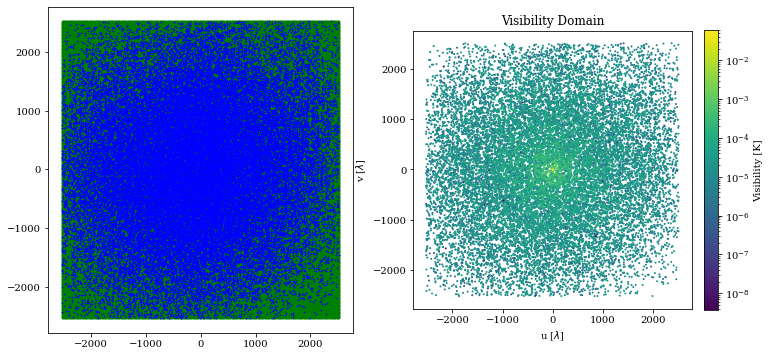

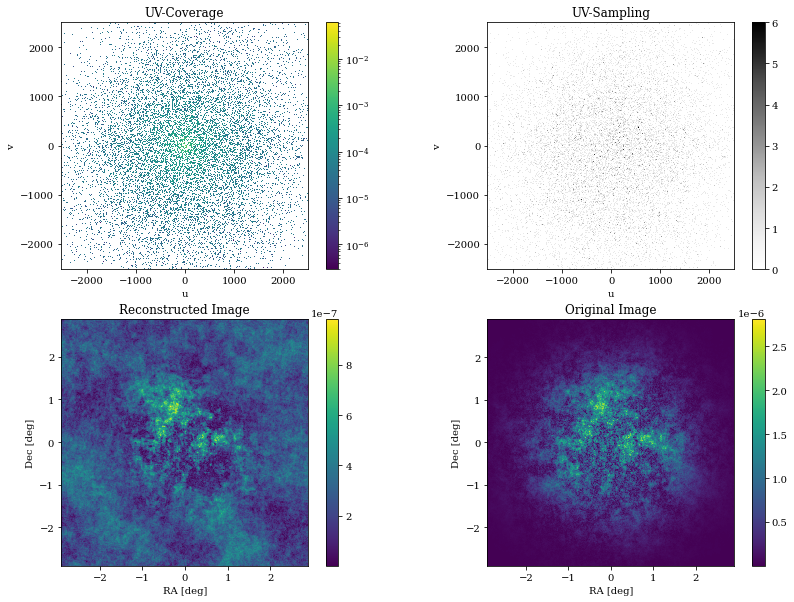

In [11]:
filter_bls, filter_vis = filter_baselines_cupy(bls_rndm, visls_rndm, u_freq, v_freq)

filter_bls = cp.asnumpy(filter_bls)
filter_vis = cp.asnumpy(filter_vis)

fig, axs= plt.subplots(1, 2, figsize=(12, 6))
axs[0].scatter(u_freq, v_freq, color='green', s=0.5)
axs[0].scatter(filter_bls[:, 0], filter_bls[:, 1], color='blue', s=0.5)

im = axs[1].scatter(x=filter_bls[:,0], y=filter_bls[:,1], c=filter_vis.real, s=1, norm=LogNorm())
axs[1].set_xlabel(r'u [$\lambda$]')
axs[1].set_ylabel(r'v [$\lambda$]')
axs[1].set_title('Visibility Domain')
axs[1].set_box_aspect(1)
plt.colorbar(im, ax= axs[1], label='Visibility [K]', fraction=0.046, pad=0.04)

binned_rndm, uv_bin_rndm, uv_sampl_rndm, x_rndm_nobeam= image_reconstructing_func(filter_vis, filter_bls, uu[0], uu[-1], len(uu), 1)

fig, axs= plt.subplots(2, 2, figsize=(14, 10))

im0= axs[0,0].pcolormesh(uv_bin_rndm, uv_bin_rndm, np.abs(binned_rndm), norm=LogNorm(), cmap='viridis')
axs[0,0].set_title('UV-Coverage')
axs[0,0].set_xlabel('u')
axs[0,0].set_ylabel('v')
axs[0,0].set_box_aspect(1)
plt.colorbar(im0, ax=axs[0,0])

im1= axs[0,1].pcolormesh(uv_bin_rndm, uv_bin_rndm, uv_sampl_rndm, cmap='Greys')
axs[0,1].set_title('UV-Sampling')
axs[0,1].set_xlabel('u')
axs[0,1].set_ylabel('v')
axs[0,1].set_box_aspect(1)
plt.colorbar(im1, ax=axs[0,1])

synchro_reconstructed_rotflip_nobeam= np.flip(np.rot90(np.fft.fftshift(np.abs(np.fft.ifft2(binned_rndm))), k=-1), axis=1)
im2= axs[1,0].pcolormesh(np.rad2deg(x_rndm_nobeam*u.rad).value, np.rad2deg(x_rndm_nobeam*u.rad).value, 
                        synchro_reconstructed_rotflip_nobeam, cmap='viridis')
axs[1,0].set_title('Reconstructed Image')
axs[1,0].set_xlabel('RA [deg]')
axs[1,0].set_ylabel('Dec [deg]')
axs[1,0].set_box_aspect(1)
plt.colorbar(im2, ax=axs[1,0])

im3= axs[1,1].pcolormesh(np.rad2deg(l_coord*u.rad).value, np.rad2deg(m_coord*u.rad).value, synchro_source * beam_pattern, cmap='viridis')
axs[1,1].set_title('Original Image')
axs[1,1].set_xlabel('RA [deg]')
axs[1,1].set_ylabel('Dec [deg]')
axs[1,1].set_box_aspect(1)
plt.colorbar(im3, ax=axs[1,1])

Length of input arrays:  50707
Time to sort and bin values:  1.543527364730835 s
Bin 1: 2536 elements - Combinations: 3214380
Bin 2: 2536 elements - Combinations: 3214380
Bin 3: 2536 elements - Combinations: 3214380
Bin 4: 2536 elements - Combinations: 3214380
Bin 5: 2536 elements - Combinations: 3214380
Bin 6: 2536 elements - Combinations: 3214380
Bin 7: 2536 elements - Combinations: 3214380
Bin 8: 2535 elements - Combinations: 3211845
Bin 9: 2535 elements - Combinations: 3211845
Bin 10: 2535 elements - Combinations: 3211845
Bin 11: 2535 elements - Combinations: 3211845
Bin 12: 2535 elements - Combinations: 3211845
Bin 13: 2535 elements - Combinations: 3211845
Bin 14: 2535 elements - Combinations: 3211845
Bin 15: 2535 elements - Combinations: 3211845
Bin 16: 2535 elements - Combinations: 3211845
Bin 17: 2535 elements - Combinations: 3211845
Bin 18: 2535 elements - Combinations: 3211845
Bin 19: 2535 elements - Combinations: 3211845
Bin 20: 2535 elements - Combinations: 3211845
Total el

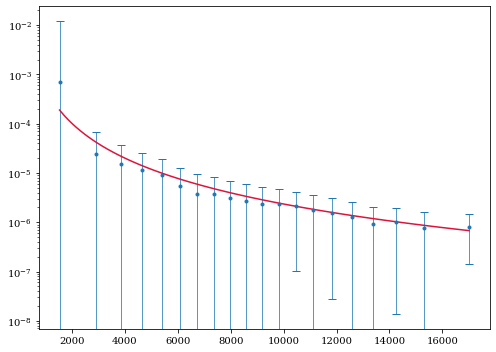

In [14]:
num_bins = 20
binning_method = 'equal_length'

bare_estimator_rndm, ell_mean_rndm, var_squared_rndm= bare_estimator_func_cupy(filter_bls, filter_vis, theta_fwhm, num_bins, binning_method)
#bare_estimator_rndm, ell_mean_rndm, var_squared_rndm= bare_estimator_func_cupy(bls_rndm, visls_rndm, theta_fwhm, num_bins, binning_method)
#bare_estimator_rndm, ell_mean_rndm= bare_estimator_func_v2(filter_bls, filter_vis, rshift, 45, 20, 'log')

fig, axes = plt.subplots(1, 1, figsize=(7, 5))

axes.errorbar(ell_mean_rndm, bare_estimator_rndm, np.sqrt(var_squared_rndm), 
              color="#1f77b4",
              label="Gaussian primary beam",
              elinewidth=0.75,
              capsize=4,
              fmt="o",
              markersize=3)
ells_rndm = np.linspace(ell_mean_rndm[0], ell_mean_rndm[-1], 100)
axes.plot(ells_rndm, 5.13 * 1e-4 * (1000 / ells_rndm) ** 2.34, color='#DC143C')
axes.set_yscale('log')
plt.tight_layout()
plt.show()

***
## __Bare estimator for SKA-low layout.__

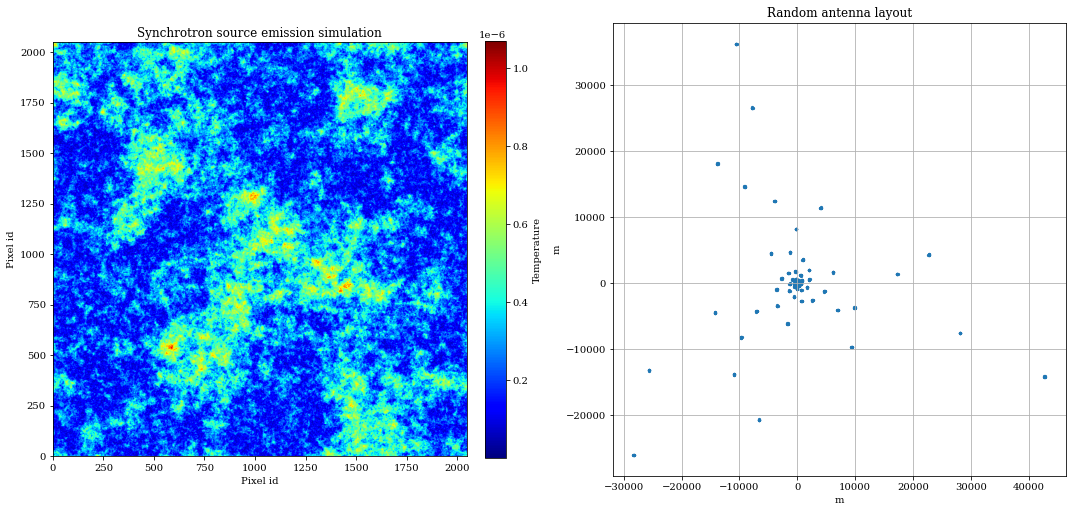

100%|██████████| 130816/130816 [11:48<00:00, 184.55it/s]


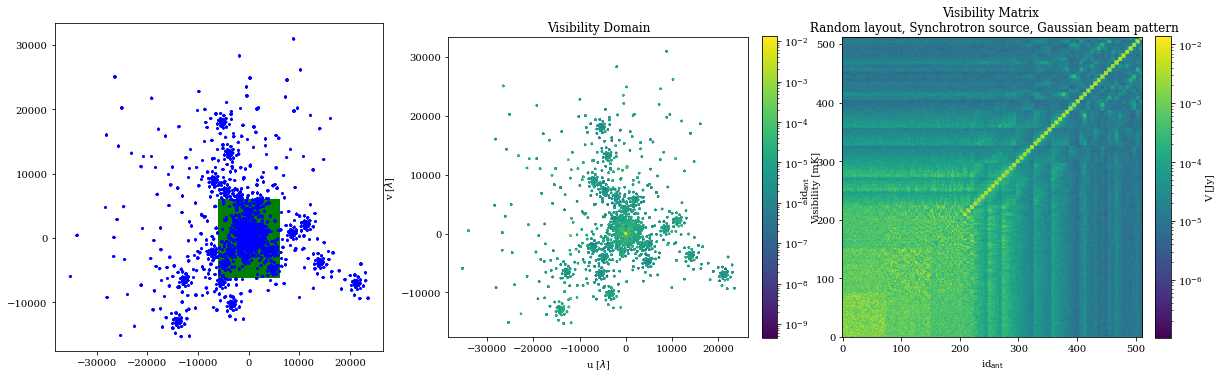

In [20]:
FoV= 10.*u.deg

# define a 1D sky and get RA coordinate
thet = np.linspace(-FoV/2, FoV/2, 2048).to('rad').value

# Create a grid of points (we ignore third dimension, i.e. n-axis)
l_coord, m_coord = np.meshgrid(thet, thet)
lmn_coord = np.dstack((l_coord, m_coord)).reshape(-1, 2)

#***********************************************
# Load the SKA-low layout
skalow_layout = np.loadtxt('SKA_material/skalow_layout.txt')
#***********************************************

# Angular diameter distance (in Mpc) for a specified redshift and FoV in deg
rshift=8.52
com_dist= FoV.to('rad').value * t2c.cosmo.z_to_cdist(rshift)

#Computing theta_fwhm
freq = t2c.cosmo.z_to_nu(rshift) * 10**6
lam = cst.c.value / freq
D = 45    
theta_fwhm= 1.03*lam / D

# Gaussian and synchrotron sources, beam pattern
synchro_source, l= synchrotron_image(rshift, len(thet), com_dist, seed=2024)
beam_pattern= telescope_beam_pattern(l_coord, m_coord, D=45, z=rshift)

#***********************************************
fig, axes = plt.subplots(1, 2, figsize=(15, 10))

im1 = axes[0].imshow(synchro_source, cmap='jet', origin= 'lower')
axes[0].set_title("Synchrotron source emission simulation")
axes[0].set_ylabel('Pixel id')
axes[0].set_xlabel('Pixel id')
axes[0].set_box_aspect(1)
plt.colorbar(im1, ax=axes[0], label='Temperature', fraction=0.046, pad=0.04)

axes[1].scatter(skalow_layout[:, 0], skalow_layout[:, 1], s=5)
axes[1].set_xlabel("m")
axes[1].set_ylabel("m")
axes[1].set_title("Random antenna layout")
axes[1].grid()
axes[1].set_box_aspect(1)

plt.tight_layout()
plt.show()


visls_ska, vismx_ska, bls_ska = visibility_matrix_func_new_method_cupy(skalow_layout, thet, rshift, synchro_source, beam_pattern)

# Computing the frequency range of the FFT image
uu= np.fft.fftfreq(synchro_source.shape[0], np.diff(thet)[0])
vv= np.fft.fftfreq(synchro_source.shape[1], np.diff(thet)[0])
uu= np.fft.fftshift(uu)
vv= np.fft.fftshift(vv)
u_freq, v_freq= np.meshgrid(uu, vv)

fig, axes= plt.subplots(1, 3, figsize=(20, 8))
axes[0].scatter(u_freq, v_freq, color='green', s=0.5)
axes[0].scatter(bls_ska[:, 0], bls_ska[:, 1], color='blue', s=0.5, label="Random layout")
axes[0].set_box_aspect(1)

im = axes[1].scatter(x=bls_ska[:,0], y=bls_ska[:,1], c=visls_ska.real, s=1, norm=LogNorm())
axes[1].set_xlabel(r'u [$\lambda$]')
axes[1].set_ylabel(r'v [$\lambda$]')
axes[1].set_title('Visibility Domain')
axes[1].set_box_aspect(1)
plt.colorbar(im, ax= axes[1], label='Visibility [mK]', fraction=0.046, pad=0.04)

im2= axes[2].imshow(np.abs(vismx_ska), origin='lower', cmap='viridis', norm=LogNorm())
axes[2].set_xlabel(r'id$_\mathrm{ant}$')
axes[2].set_ylabel(r'id$_\mathrm{ant}$')
axes[2].set_title('Visibility Matrix \n Random layout, Synchrotron source, Gaussian beam pattern')
axes[2].set_box_aspect(1)
plt.colorbar(im2, ax=axes[2], label='V [Jy]', fraction=0.046, pad=0.04)

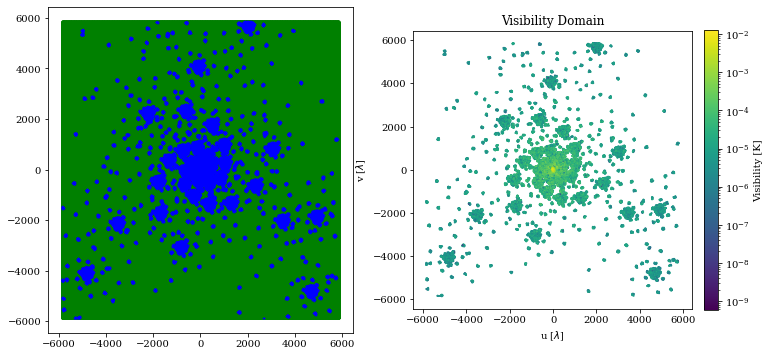

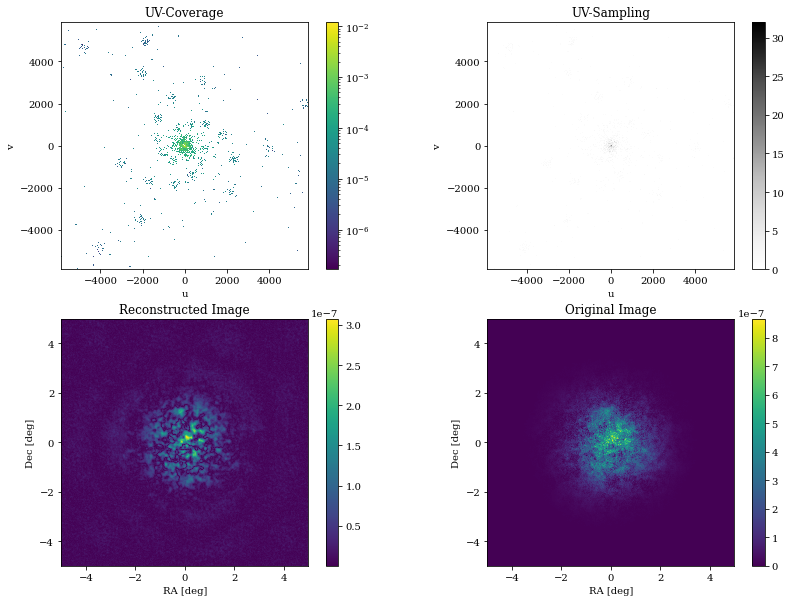

In [21]:
filter_bls, filter_vis = filter_baselines_cupy(bls_ska, visls_ska, u_freq, v_freq)

filter_bls = cp.asnumpy(filter_bls)
filter_vis = cp.asnumpy(filter_vis)

fig, axs= plt.subplots(1, 2, figsize=(12, 6))
axs[0].scatter(u_freq, v_freq, color='green', s=0.5)
axs[0].scatter(filter_bls[:, 0], filter_bls[:, 1], color='blue', s=0.5)

im = axs[1].scatter(x=filter_bls[:,0], y=filter_bls[:,1], c=filter_vis.real, s=1, norm=LogNorm())
axs[1].set_xlabel(r'u [$\lambda$]')
axs[1].set_ylabel(r'v [$\lambda$]')
axs[1].set_title('Visibility Domain')
axs[1].set_box_aspect(1)
plt.colorbar(im, ax= axs[1], label='Visibility [K]', fraction=0.046, pad=0.04)

binned_ska, uv_bin_ska, uv_sampl_ska, x_ska_nobeam= image_reconstructing_func(filter_vis, filter_bls, uu[0], uu[-1], len(uu), 1)

fig, axs= plt.subplots(2, 2, figsize=(14, 10))

im0= axs[0,0].pcolormesh(uv_bin_ska, uv_bin_ska, np.abs(binned_ska), norm=LogNorm(), cmap='viridis')
axs[0,0].set_title('UV-Coverage')
axs[0,0].set_xlabel('u')
axs[0,0].set_ylabel('v')
axs[0,0].set_box_aspect(1)
plt.colorbar(im0, ax=axs[0,0])

im1= axs[0,1].pcolormesh(uv_bin_ska, uv_bin_ska, uv_sampl_ska, cmap='Greys')
axs[0,1].set_title('UV-Sampling')
axs[0,1].set_xlabel('u')
axs[0,1].set_ylabel('v')
axs[0,1].set_box_aspect(1)
plt.colorbar(im1, ax=axs[0,1])

synchro_reconstructed_rotflip_nobeam= np.flip(np.rot90(np.fft.fftshift(np.abs(np.fft.ifft2(binned_ska))), k=-1), axis=1)
im2= axs[1,0].pcolormesh(np.rad2deg(x_ska_nobeam*u.rad).value, np.rad2deg(x_ska_nobeam*u.rad).value, 
                        synchro_reconstructed_rotflip_nobeam, cmap='viridis')
axs[1,0].set_title('Reconstructed Image')
axs[1,0].set_xlabel('RA [deg]')
axs[1,0].set_ylabel('Dec [deg]')
axs[1,0].set_box_aspect(1)
plt.colorbar(im2, ax=axs[1,0])

im3= axs[1,1].pcolormesh(np.rad2deg(l_coord*u.rad).value, np.rad2deg(m_coord*u.rad).value, synchro_source * beam_pattern, cmap='viridis')
axs[1,1].set_title('Original Image')
axs[1,1].set_xlabel('RA [deg]')
axs[1,1].set_ylabel('Dec [deg]')
axs[1,1].set_box_aspect(1)
plt.colorbar(im3, ax=axs[1,1])

Length of input arrays:  91304
Time to sort and bin values:  0.002818584442138672 s
Bin 1: 2283 elements - Combinations: 2604903
Bin 2: 2283 elements - Combinations: 2604903
Bin 3: 2283 elements - Combinations: 2604903
Bin 4: 2283 elements - Combinations: 2604903
Bin 5: 2283 elements - Combinations: 2604903
Bin 6: 2283 elements - Combinations: 2604903
Bin 7: 2283 elements - Combinations: 2604903
Bin 8: 2283 elements - Combinations: 2604903
Bin 9: 2283 elements - Combinations: 2604903
Bin 10: 2283 elements - Combinations: 2604903
Bin 11: 2283 elements - Combinations: 2604903
Bin 12: 2283 elements - Combinations: 2604903
Bin 13: 2283 elements - Combinations: 2604903
Bin 14: 2283 elements - Combinations: 2604903
Bin 15: 2283 elements - Combinations: 2604903
Bin 16: 2283 elements - Combinations: 2604903
Bin 17: 2283 elements - Combinations: 2604903
Bin 18: 2283 elements - Combinations: 2604903
Bin 19: 2283 elements - Combinations: 2604903
Bin 20: 2283 elements - Combinations: 2604903
Bin 2

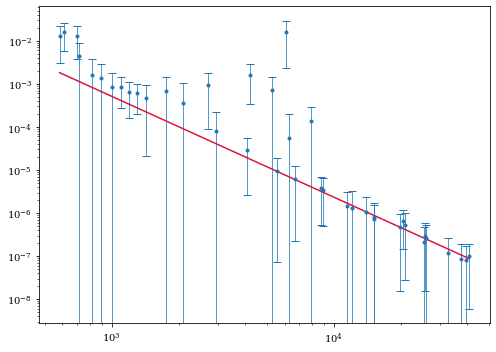

In [36]:
num_bins = 40
binning_method = 'equal_length'

bare_estimator_ska, ell_mean_ska, var_squared_ska= bare_estimator_func_cupy(filter_bls, filter_vis, theta_fwhm, num_bins, binning_method)

fig, axes = plt.subplots(1, 1, figsize=(7, 5))

axes.errorbar(ell_mean_ska, bare_estimator_ska, np.sqrt(var_squared_ska), 
              color="#1f77b4",
              label="Gaussian primary beam",
              elinewidth=0.75,
              capsize=4,
              fmt="o",
              markersize=3)
ells_ska = np.linspace(cp.min(ell_mean_ska), cp.max(ell_mean_ska), 100)
axes.plot(ells_ska, 5.13 * 1e-4 * (1000 / ells_ska) ** 2.34, color='#DC143C')
axes.set_yscale('log')
axes.set_xscale('log')
plt.tight_layout()
plt.show()

***
## __Trying again for the .MS file antenna positions.__

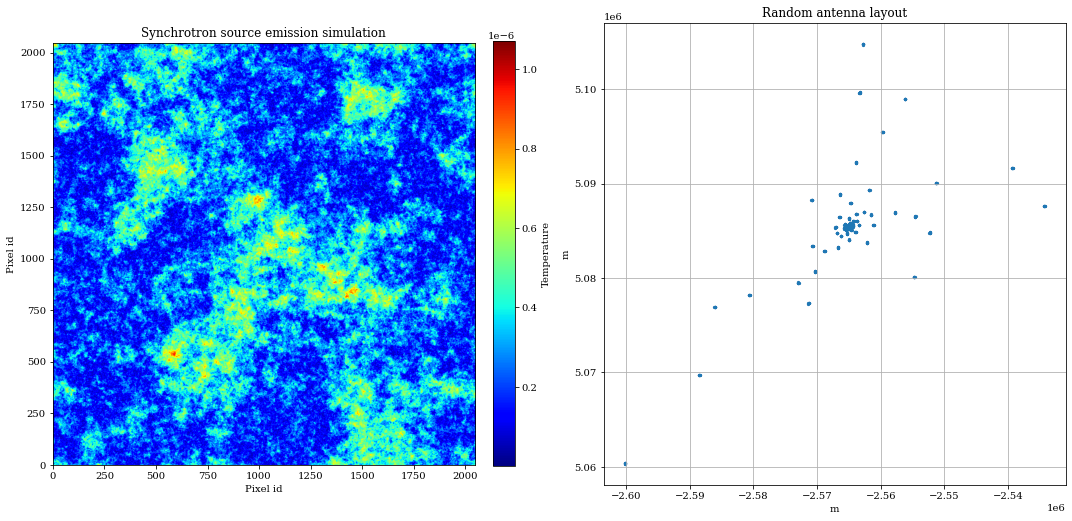

100%|██████████| 130816/130816 [11:48<00:00, 184.55it/s]


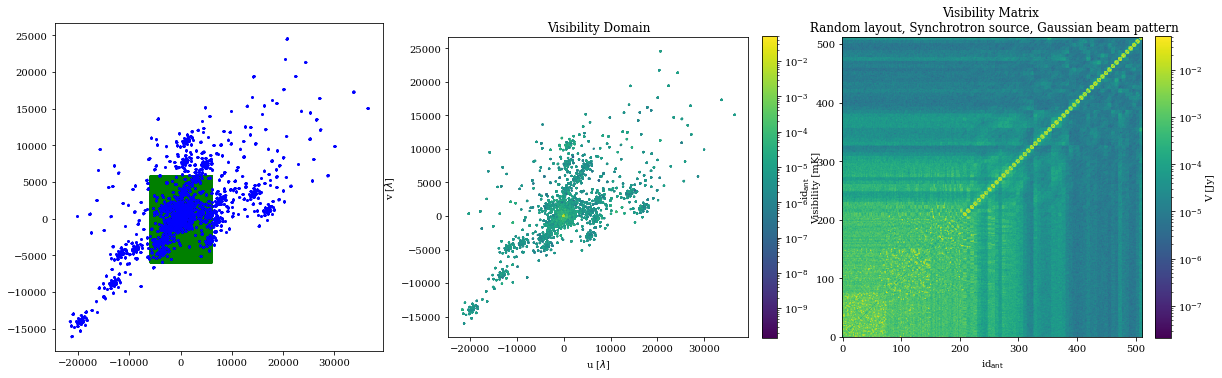

In [57]:
FoV= 10.*u.deg

# define a 1D sky and get RA coordinate
thet = np.linspace(-FoV/2, FoV/2, 2048).to('rad').value

# Create a grid of points (we ignore third dimension, i.e. n-axis)
l_coord, m_coord = np.meshgrid(thet, thet)
lmn_coord = np.dstack((l_coord, m_coord)).reshape(-1, 2)

#***********************************************
# Load the SKA-low layout
skalow_layout = np.load('SKA_material/SKA_ant_coords.npy')
#***********************************************

# Angular diameter distance (in Mpc) for a specified redshift and FoV in deg
frequency_MHz = 166
rshift= t2c.cosmo.nu_to_z(frequency_MHz)
com_dist= FoV.to('rad').value * t2c.cosmo.z_to_cdist(rshift)

#Computing theta_fwhm
theta_maj= 0.0441370233211219
theta_min= 0.0329175084774813
theta_fwhm = np.mean([theta_maj, theta_min])

# Gaussian and synchrotron sources, beam pattern
synchro_source, l= synchrotron_image(rshift, len(thet), com_dist, seed=2024)
beam_pattern= telescope_beam_pattern_thetafwhm(l_coord, m_coord, theta_fwhm)

#***********************************************
fig, axes = plt.subplots(1, 2, figsize=(15, 10))

im1 = axes[0].imshow(synchro_source, cmap='jet', origin= 'lower')
axes[0].set_title("Synchrotron source emission simulation")
axes[0].set_ylabel('Pixel id')
axes[0].set_xlabel('Pixel id')
axes[0].set_box_aspect(1)
plt.colorbar(im1, ax=axes[0], label='Temperature', fraction=0.046, pad=0.04)

axes[1].scatter(skalow_layout[:, 0], skalow_layout[:, 1], s=5)
axes[1].set_xlabel("m")
axes[1].set_ylabel("m")
axes[1].set_title("Random antenna layout")
axes[1].grid()
axes[1].set_box_aspect(1)

plt.tight_layout()
plt.show()


visls_ska, vismx_ska, bls_ska = visibility_matrix_func_new_method_cupy(skalow_layout, thet, rshift, synchro_source, beam_pattern)

# Computing the frequency range of the FFT image
uu= np.fft.fftfreq(synchro_source.shape[0], np.diff(thet)[0])
vv= np.fft.fftfreq(synchro_source.shape[1], np.diff(thet)[0])
uu= np.fft.fftshift(uu)
vv= np.fft.fftshift(vv)
u_freq, v_freq= np.meshgrid(uu, vv)

fig, axes= plt.subplots(1, 3, figsize=(20, 8))
axes[0].scatter(u_freq, v_freq, color='green', s=0.5)
axes[0].scatter(bls_ska[:, 0], bls_ska[:, 1], color='blue', s=0.5, label="Random layout")
axes[0].set_box_aspect(1)

im = axes[1].scatter(x=bls_ska[:,0], y=bls_ska[:,1], c=visls_ska.real, s=1, norm=LogNorm())
axes[1].set_xlabel(r'u [$\lambda$]')
axes[1].set_ylabel(r'v [$\lambda$]')
axes[1].set_title('Visibility Domain')
axes[1].set_box_aspect(1)
plt.colorbar(im, ax= axes[1], label='Visibility [mK]', fraction=0.046, pad=0.04)

im2= axes[2].imshow(np.abs(vismx_ska), origin='lower', cmap='viridis', norm=LogNorm())
axes[2].set_xlabel(r'id$_\mathrm{ant}$')
axes[2].set_ylabel(r'id$_\mathrm{ant}$')
axes[2].set_title('Visibility Matrix \n Random layout, Synchrotron source, Gaussian beam pattern')
axes[2].set_box_aspect(1)
plt.colorbar(im2, ax=axes[2], label='V [Jy]', fraction=0.046, pad=0.04)

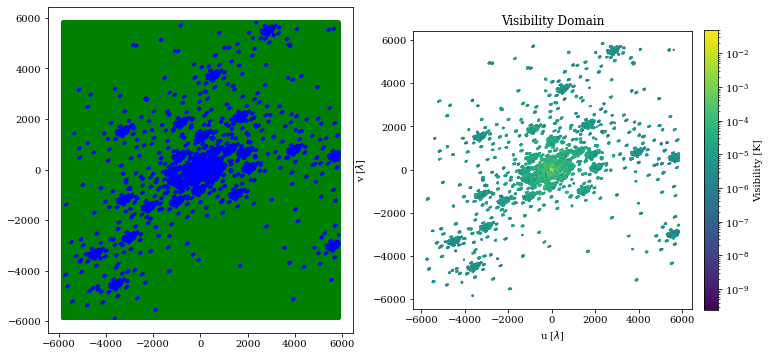

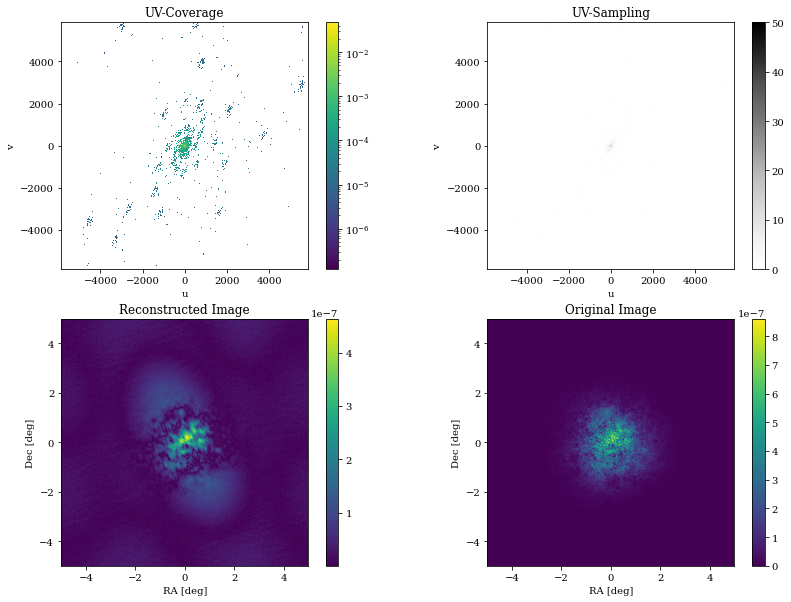

In [58]:
filter_bls, filter_vis = filter_baselines_cupy(bls_ska, visls_ska, u_freq, v_freq)

filter_bls = cp.asnumpy(filter_bls)
filter_vis = cp.asnumpy(filter_vis)

fig, axs= plt.subplots(1, 2, figsize=(12, 6))
axs[0].scatter(u_freq, v_freq, color='green', s=0.5)
axs[0].scatter(filter_bls[:, 0], filter_bls[:, 1], color='blue', s=0.5)

im = axs[1].scatter(x=filter_bls[:,0], y=filter_bls[:,1], c=filter_vis.real, s=1, norm=LogNorm())
axs[1].set_xlabel(r'u [$\lambda$]')
axs[1].set_ylabel(r'v [$\lambda$]')
axs[1].set_title('Visibility Domain')
axs[1].set_box_aspect(1)
plt.colorbar(im, ax= axs[1], label='Visibility [K]', fraction=0.046, pad=0.04)

binned_ska, uv_bin_ska, uv_sampl_ska, x_ska_nobeam= image_reconstructing_func(filter_vis, filter_bls, uu[0], uu[-1], len(uu), 1)

fig, axs= plt.subplots(2, 2, figsize=(14, 10))

im0= axs[0,0].pcolormesh(uv_bin_ska, uv_bin_ska, np.abs(binned_ska), norm=LogNorm(), cmap='viridis')
axs[0,0].set_title('UV-Coverage')
axs[0,0].set_xlabel('u')
axs[0,0].set_ylabel('v')
axs[0,0].set_box_aspect(1)
plt.colorbar(im0, ax=axs[0,0])

im1= axs[0,1].pcolormesh(uv_bin_ska, uv_bin_ska, uv_sampl_ska, cmap='Greys')
axs[0,1].set_title('UV-Sampling')
axs[0,1].set_xlabel('u')
axs[0,1].set_ylabel('v')
axs[0,1].set_box_aspect(1)
plt.colorbar(im1, ax=axs[0,1])

synchro_reconstructed_rotflip_nobeam= np.flip(np.rot90(np.fft.fftshift(np.abs(np.fft.ifft2(binned_ska))), k=-1), axis=1)
im2= axs[1,0].pcolormesh(np.rad2deg(x_ska_nobeam*u.rad).value, np.rad2deg(x_ska_nobeam*u.rad).value, 
                        synchro_reconstructed_rotflip_nobeam, cmap='viridis')
axs[1,0].set_title('Reconstructed Image')
axs[1,0].set_xlabel('RA [deg]')
axs[1,0].set_ylabel('Dec [deg]')
axs[1,0].set_box_aspect(1)
plt.colorbar(im2, ax=axs[1,0])

im3= axs[1,1].pcolormesh(np.rad2deg(l_coord*u.rad).value, np.rad2deg(m_coord*u.rad).value, synchro_source * beam_pattern, cmap='viridis')
axs[1,1].set_title('Original Image')
axs[1,1].set_xlabel('RA [deg]')
axs[1,1].set_ylabel('Dec [deg]')
axs[1,1].set_box_aspect(1)
plt.colorbar(im3, ax=axs[1,1])

Length of input arrays:  98287
Time to sort and bin values:  0.002504110336303711 s
Bin 1: 2458 elements - Combinations: 3019653
Bin 2: 2458 elements - Combinations: 3019653
Bin 3: 2458 elements - Combinations: 3019653
Bin 4: 2458 elements - Combinations: 3019653
Bin 5: 2458 elements - Combinations: 3019653
Bin 6: 2458 elements - Combinations: 3019653
Bin 7: 2458 elements - Combinations: 3019653
Bin 8: 2457 elements - Combinations: 3017196
Bin 9: 2457 elements - Combinations: 3017196
Bin 10: 2457 elements - Combinations: 3017196
Bin 11: 2457 elements - Combinations: 3017196
Bin 12: 2457 elements - Combinations: 3017196
Bin 13: 2457 elements - Combinations: 3017196
Bin 14: 2457 elements - Combinations: 3017196
Bin 15: 2457 elements - Combinations: 3017196
Bin 16: 2457 elements - Combinations: 3017196
Bin 17: 2457 elements - Combinations: 3017196
Bin 18: 2457 elements - Combinations: 3017196
Bin 19: 2457 elements - Combinations: 3017196
Bin 20: 2457 elements - Combinations: 3017196
Bin 2

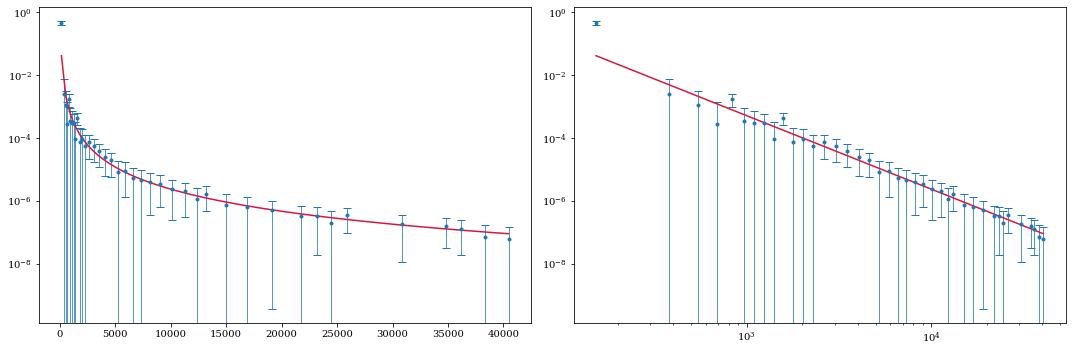

In [59]:
num_bins = 40
binning_method = 'equal_length'

bare_estimator_ska, ell_mean_ska, var_squared_ska= bare_estimator_func_cupy(filter_bls, filter_vis, theta_fwhm, num_bins, binning_method)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].errorbar(ell_mean_ska, bare_estimator_ska, np.sqrt(var_squared_ska), 
              color="#1f77b4",
              label="Gaussian primary beam",
              elinewidth=0.75,
              capsize=4,
              fmt="o",
              markersize=3)
ells_ska = np.linspace(cp.min(ell_mean_ska), cp.max(ell_mean_ska), 100)
axes[0].plot(ells_ska, 5.13 * 1e-4 * (1000 / ells_ska) ** 2.34, color='#DC143C')
axes[0].set_yscale('log')
#axes[0].set_xscale('log')

axes[1].errorbar(ell_mean_ska, bare_estimator_ska, np.sqrt(var_squared_ska), 
              color="#1f77b4",
              label="Gaussian primary beam",
              elinewidth=0.75,
              capsize=4,
              fmt="o",
              markersize=3)
axes[1].plot(ells_ska, 5.13 * 1e-4 * (1000 / ells_ska) ** 2.34, color='#DC143C')
axes[1].set_yscale('log')
axes[1].set_xscale('log')

plt.tight_layout()
plt.show()

In [61]:
freq = 166 * 1e6
lam = cst.c.value / freq
print(lam)

1.8059786626506025
